In [1]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_hmc_config
import arviz as az
from define_data_and_variables import hmc_config, data, hash_configs
import os

In [2]:
base_path = "../../../../data/"
output_dir = os.path.join(base_path, data["dn"])

In [3]:
cutout = 1000
energy_values = np.load(f"{output_dir}/energy.npy")[:, cutout:]
samples = np.load(f"{output_dir}/samples.npy")[:, cutout:]

In [4]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

In [5]:
# Print R_hat and N_eff using arviz
idata = az.convert_to_inference_data(samples)
summary = az.summary(idata, round_to=2)
print(summary)

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd    ess_bulk  \
x[0]    5.02   0.90    3.27     6.46       0.00     0.00   844786.84   
x[1]    5.86   3.50    0.86    12.54       0.01     0.01  1320345.69   
x[2]    5.26   3.22    0.77    11.21       0.00     0.01   814241.88   
x[3]    5.26   3.21    0.78    11.19       0.00     0.01   834005.70   
x[4]    5.26   3.22    0.74    11.21       0.00     0.01   828213.92   
x[5]    5.26   3.21    0.73    11.19       0.00     0.01   830727.16   
x[6]    5.26   3.21    0.74    11.19       0.00     0.01   807145.73   
x[7]    5.26   3.21    0.78    11.23       0.00     0.01   788428.46   
x[8]    5.25   3.20    0.78    11.19       0.00     0.01   778267.12   
x[9]    5.26   3.21    0.76    11.23       0.00     0.01   832414.59   
x[10]   5.26   3.21    0.72    11.17       0.00     0.01   853344.44   
x[11]   5.26   3.22    0.73    11.20       0.00     0.01   835875.45   
x[12]   5.27   3.23    0.74    11.24       0.00     0.01   87224

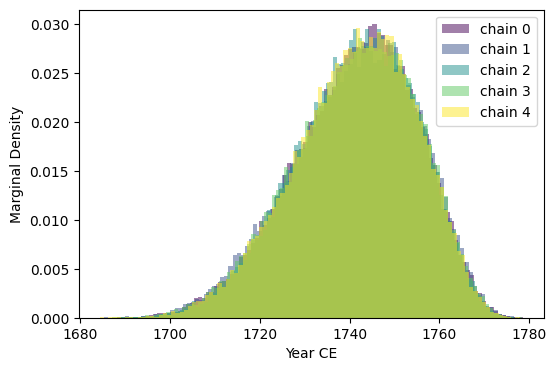

In [6]:
colors = plt.cm.viridis(np.linspace(0, 1, hmc_config["nch"]))
index = 21
interesting_depth = index * data["dc"]
CV_values = data["th"] - data["dc"] * np.sum(samples[:, 5000:, :index], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(hmc_config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.xlabel("Year CE")
plt.ylabel("Marginal Density")
plt.legend()
plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}.jpg")
plt.show()

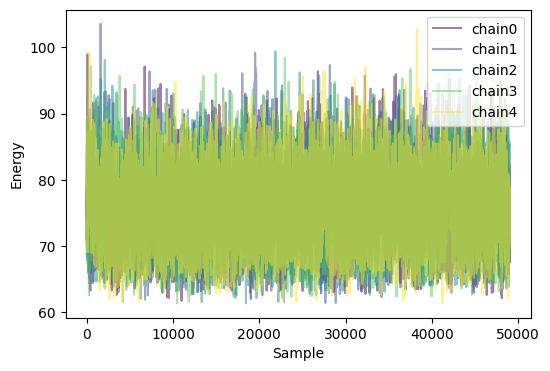

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(hmc_config["nch"]):
    ax.plot(energy_values[i, :], color = colors[i], alpha = 0.5, label = f"chain{i}")
plt.legend()
plt.xlabel("Sample")
plt.ylabel("Energy")
plt.savefig(f"{output_dir}/energy_evol.jpg")
plt.show()   